In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
from statsmodels.distributions.empirical_distribution import ECDF

# import shutil
# import re
# import os

# Ahora importa el módulo
from RRAM.Representate import config_ax, setup_paper_plt
    
setup_paper_plt(plt, latex=True, scaling=2)

In [2]:
ruta_datos = Path.cwd() / "Datos_Experimentales" / "Medidas_Experimentales_RRAM"
ruta_figuras = Path.cwd() / "Datos_Experimentales" / "V_Set"

In [3]:
results_path = ruta_figuras / "V_set_simulacion.txt"

resultados_txt = np.genfromtxt(
    results_path,
    dtype=[
        ("Archivo", "U50"),  # String Unicode de máx 50 caracteres
        ("V_set", "f8"),  # Float de 64 bits
    ],
    encoding="utf-8",
    names=["Archivo", "V_set"],
)

# Crear un DataFrame para una mejor visualización
df_resultados_sim = pd.DataFrame(resultados_txt)

df_resultados_sim["Numero"] = (
    df_resultados_sim["Archivo"]
    .str.extract(r"log_simulacion_(\d+)", expand=False)
    .astype(int)
)

print(df_resultados_sim)

                    Archivo   V_set  Numero
0      log_simulacion_1.log  0.4729       1
1     log_simulacion_10.log  0.4981      10
2    log_simulacion_100.log  0.4549     100
3    log_simulacion_101.log  0.4949     101
4    log_simulacion_102.log  0.5107     102
..                      ...     ...     ...
395   log_simulacion_95.log  0.5160      95
396   log_simulacion_96.log  0.4627      96
397   log_simulacion_97.log  0.5249      97
398   log_simulacion_98.log  0.5032      98
399   log_simulacion_99.log  0.4523      99

[400 rows x 3 columns]


In [4]:
results_path = ruta_figuras / "V_set_experimental.txt"

resultados_txt = np.genfromtxt(
    results_path,
    dtype=[
        ("Archivo", "U50"),  # String Unicode de máx 50 caracteres
        ("V_set_derivada", "f8"),  # Float de 64 bits
        ("V_set_elbow", "f8"),
    ],
    encoding="utf-8",
    names=["Archivo", "V_set_derivada_V", "V_set_elbow_V"],
)

# Crear un DataFrame para una mejor visualización
df_resultados_exp = pd.DataFrame(resultados_txt)

df_resultados_exp["Numero"] = (
    df_resultados_exp["Archivo"].str.extract(r"Cycle_p_(\d+)", expand=False).astype(int)
)

print(df_resultados_exp)

          Archivo  V_set_derivada_V  V_set_elbow_V  Numero
0    Cycle_p_1000              0.53           0.52    1000
1    Cycle_p_1001              0.50           0.54    1001
2    Cycle_p_1002              0.49           0.54    1002
3    Cycle_p_1003              0.47           0.47    1003
4    Cycle_p_1004              0.51           0.50    1004
..            ...               ...            ...     ...
396   Cycle_p_995              0.52           0.51     995
397   Cycle_p_996              0.55           0.53     996
398   Cycle_p_997              0.51           0.50     997
399   Cycle_p_998              0.52           0.52     998
400   Cycle_p_999              0.54           0.54     999

[401 rows x 4 columns]


V_set_sim: (400,), V_set_exp_der: (401,), V_set_exp_elbow: (401,)


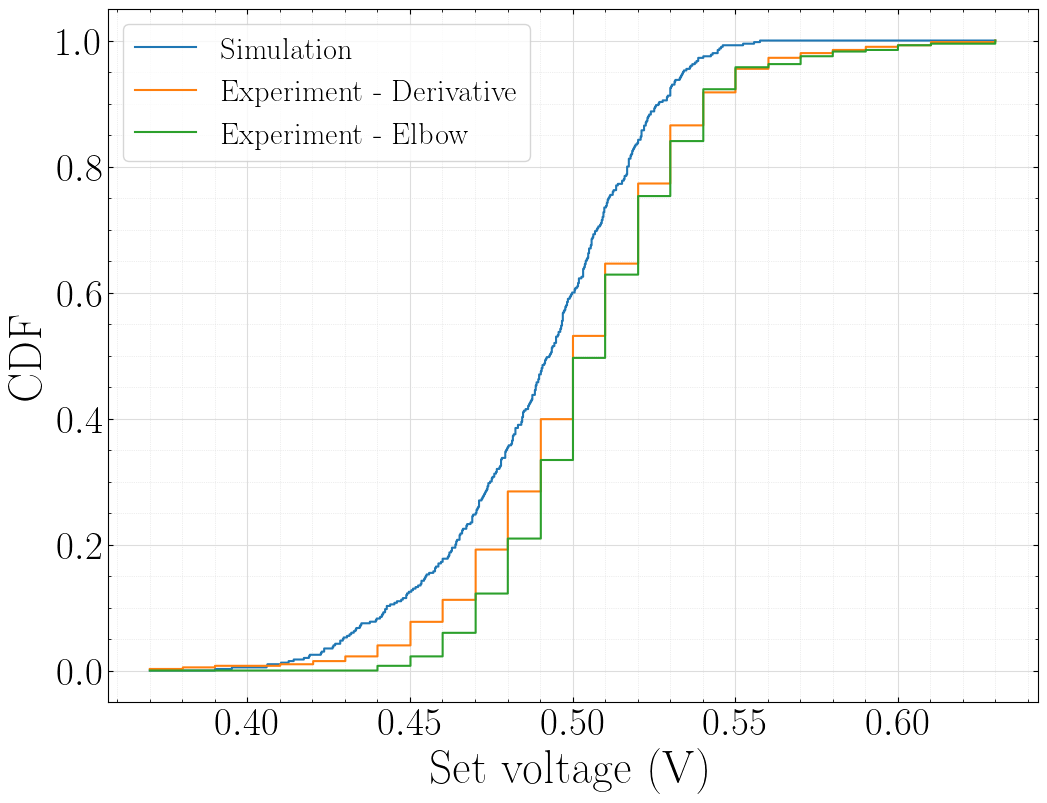

In [5]:
V_set_sim = df_resultados_sim["V_set"]
V_set_exp_der = df_resultados_exp["V_set_derivada_V"]
V_set_exp_elbow = df_resultados_exp["V_set_elbow_V"]

print(f"V_set_sim: {V_set_sim.shape}, V_set_exp_der: {V_set_exp_der.shape}, V_set_exp_elbow: {V_set_exp_elbow.shape}")
# ECDF objects
ecdf_sim = ECDF(V_set_sim)
ecdf_exp_der = ECDF(V_set_exp_der)
ecdf_exp_elb = ECDF(V_set_exp_elbow)

fig, ax = plt.subplots(figsize=(12, 9))
config_ax(ax)

# Common range
min_val = min(min(V_set_sim), min(V_set_exp_der), min(V_set_exp_elbow))
max_val = max(max(V_set_sim), max(V_set_exp_der), max(V_set_exp_elbow))
x = np.linspace(min_val, max_val, 1000)

# Evaluate ECDFs
y_sim = ecdf_sim(x)
y_der = ecdf_exp_der(x)
y_elb = ecdf_exp_elb(x)

# Plot ECDFs
ax.step(x, y_sim, where="post", label="Simulation")
ax.step(x, y_der, where="post", label="Experiment - Derivative")
ax.step(x, y_elb, where="post", label="Experiment - Elbow")

# Labels in English
ax.set_xlabel(r"Set voltage (\si{\volt})")
ax.set_ylabel("CDF")
ax.grid(True)
ax.legend()

plt.show()
